In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

model = YOLO("runs/detect/runs/yolo8m_violence_detection/weights/best.pt")

WARNING ⚠️ user config directory '/root/.config/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
results = model.predict(source='images/teting/fight3.jpg')


image 1/1 /workspace/images/teting/fight3.jpg: 384x640 9 non-violences, 1 violence, 1 weapon, 344.0ms
Speed: 3.6ms preprocess, 344.0ms inference, 32.5ms postprocess per image at shape (1, 3, 384, 640)


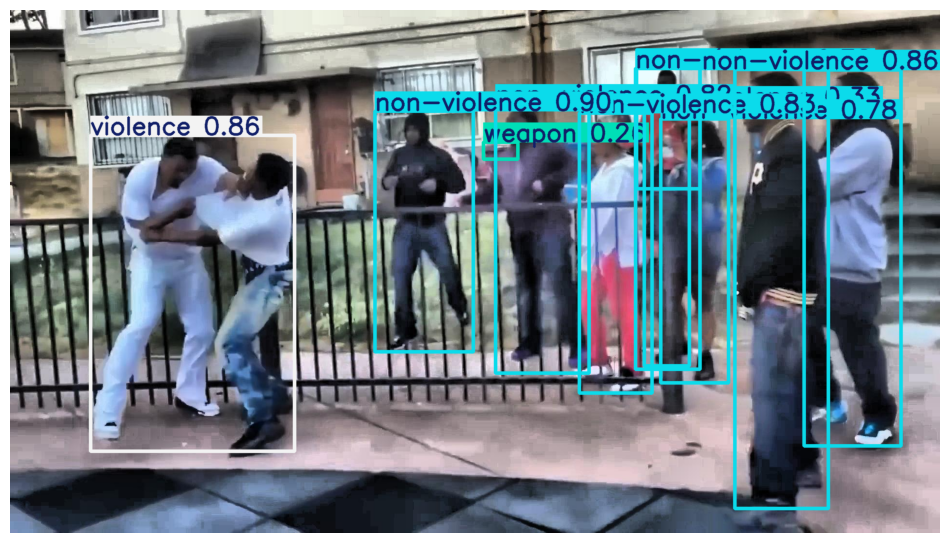

In [4]:
res = results[0]  # Get results for the single image
res_bgr = res.plot()  # This draws the boxes and labels on the image
res_rgb = cv2.cvtColor(res_bgr, cv2.COLOR_BGR2RGB) # Convert for Matplotlib

plt.figure(figsize=(12, 8))
plt.imshow(res_rgb)
plt.axis('off')
plt.show()

In [ ]:
import cv2
from ultralytics import YOLO
from collections import deque

model = YOLO('runs/detect/runs/yolo8m_violence_detection/weights/best.pt') 
video_path = 'images/teting/testvd.mp4'
cap = cv2.VideoCapture(video_path)

# Get video properties for saving
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Define the codec and create VideoWriter object
out = cv2.VideoWriter('images/teting/testvid_output177.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

window_size = 10
alert_threshold = 5
fight_buffer = deque(maxlen=window_size)

print("Processing video... Please wait.")

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    results = model.predict(frame, conf=0.6, verbose=False)
    
    detected_this_frame = False
    for box in results[0].boxes:
        if box.cls == 0: 
            detected_this_frame = True
            # Draw the bounding box on the frame
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 3)
            break
            
    fight_buffer.append(detected_this_frame)
    fight_count = sum(fight_buffer)
    
    if fight_count >= alert_threshold:
        status_text = f"ALERT: FIGHT ({fight_count}/{window_size})"
        color = (0, 0, 255)
    else :
        status_text = "Status: Normal"
        color = (0, 255, 0) 

    cv2.putText(frame, status_text, (50, 70), cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)
    
    # Write the frame to the new video file
    out.write(frame)

cap.release()
out.release()
print("Done! The video has been saved as 'fight_detection_output.mp4'.")

Processing video... Please wait.
Done! The video has been saved as 'fight_detection_output.mp4'.


# new multi classes test :


In [1]:
import cv2
from ultralytics import YOLO
from collections import deque

# 1. Load the model
model = YOLO('runs/detect/runs/yolo8m_violence_detection/weights/best.pt') 

# Get class names automatically from the model
# ['fire', 'head', 'knife', 'object', 'person', 'pistol', 'smoke', 'violence', 'nonviolence']
CLASS_NAMES = model.names 

# Define which classes trigger the RED alert
THREAT_CLASSES = [ "knife", "violence", "weapon" ]

video_path = 'images/teting/gfviolence.mp4'
cap = cv2.VideoCapture(video_path)

# Video properties
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Using 'mp4v' as you had it since the error is gone
out_path = 'images/teting/gfviolence_output10.mp4'
out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

# 2. Create a buffer for EVERY class (window of 10 frames)
window_size = 10
alert_threshold = 5
buffers = {name: deque(maxlen=window_size) for name in CLASS_NAMES.values()}

print(f"Processing video with {len(CLASS_NAMES)} classes... Please wait.")

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    results = model.predict(frame, conf=0.6, verbose=False)
    
    # Track what was seen in the CURRENT frame
    seen_this_frame = {name: False for name in CLASS_NAMES.values()}
    
    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        cls_name = CLASS_NAMES[cls_id]
        seen_this_frame[cls_name] = True
        
        # Draw bounding boxes
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        # Red for threats, Green for others
        box_color = (0, 0, 255) if cls_name in THREAT_CLASSES else (0, 255, 0)
        cv2.rectangle(frame, (x1, y1), (x2, y2), box_color, 3)
        cv2.putText(frame, cls_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_color, 2)

    # 3. Update all buffers and check which threats are active
    active_threats = []
    for name in CLASS_NAMES.values():
        buffers[name].append(seen_this_frame[name])
        
        # If a THREAT class hits the threshold, add to alert list
        if sum(buffers[name]) >= alert_threshold and name in THREAT_CLASSES:
            active_threats.append(name.upper())

    # 4. Status Bar Logic
    if active_threats:
        status_text = f"ALERT: {', '.join(active_threats)}"
        color = (0, 0, 255) # Red
    else:
        status_text = "Status: Normal"
        color = (0, 255, 0) # Green

    cv2.putText(frame, status_text, (50, 70), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
    
    out.write(frame)

cap.release()
out.release()
print(f"Done! Result saved to: {out_path}")

WARNING ⚠️ user config directory '/root/.config/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Processing video with 4 classes... Please wait.
WARNING ⚠️ NMS time limit 2.050s exceeded
Done! Result saved to: images/teting/gfviolence_output10.mp4


In [ ]:
import cv2
from ultralytics import YOLO
from collections import deque

# 1. Load the model
model = YOLO('../runs/detect/runs/1yolov8m_realy_violence2_test_v3/weights/best.pt') 

# VERIFICATION: Print class map to your console to make sure indices match
print("Model Class Mapping:", model.names)
CLASS_NAMES = model.names 

# Only 'Violence' is a threat (must match exact case from model.names)
THREAT_CLASSES = ['Violence']


video_path = 'images/teting/testvd.mp4'
cap = cv2.VideoCapture(video_path)

# Video properties
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

out_path = '../images/teting/testvid21_output.mp4'
out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

# Buffers for temporal smoothing
window_size = 10
alert_threshold = 3
buffers = {name: deque(maxlen=window_size) for name in CLASS_NAMES.values()}

print("Processing video... Check your console for class mapping.")

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    results = model.predict(frame, conf=0.4, verbose=False)
    
    seen_this_frame = {name: False for name in CLASS_NAMES.values()}
    
    if results[0].boxes:
        for box in results[0].boxes:
            cls_id = int(box.cls[0])
            cls_name = CLASS_NAMES[cls_id]
            conf_score = float(box.conf[0])
            
            seen_this_frame[cls_name] = True
            
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            
            is_threat = cls_name in THREAT_CLASSES
            color = (0, 0, 255) if is_threat else (0, 255, 0)
            
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
            label = f"{cls_name} {conf_score:.2f}"
            cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    # Update alerts
    active_threats = []
    for name in CLASS_NAMES.values():
        buffers[name].append(seen_this_frame[name])
        if sum(buffers[name]) >= alert_threshold and name in THREAT_CLASSES:
            active_threats.append(name.upper())

    # UI Status
    if active_threats:
        status_text = f"ALERT: {', '.join(active_threats)}"
        status_color = (0, 0, 255)
    else:
        status_text = "Status: Normal"
        status_color = (0, 255, 0)

    cv2.putText(frame, status_text, (50, 70), cv2.FONT_HERSHEY_SIMPLEX, 1.3, status_color, 3)
    out.write(frame)

cap.release()
out.release()
print(f"Done! Result saved to: {out_path}")

# video live display


In [2]:
import cv2
from ultralytics import YOLO
from collections import deque
from IPython.display import display, clear_output
import PIL.Image

# 1. Load the model
model = YOLO('runs/detect/runs/yolo8m_violence_detection/weights/best.pt') 
CLASS_NAMES = model.names 
THREAT_CLASSES = ['Violence']

video_path = '../images/teting/gfviolence.mp4'
cap = cv2.VideoCapture(video_path)

# Buffer settings
window_size = 10
alert_threshold = 3
buffers = {name: deque(maxlen=window_size) for name in CLASS_NAMES.values()}

try:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        # Inference
        results = model.predict(frame, conf=0.4, verbose=False)
        seen_this_frame = {name: False for name in CLASS_NAMES.values()}
        
        # Process detections
        if results[0].boxes:
            for box in results[0].boxes:
                cls_id = int(box.cls[0])
                cls_name = CLASS_NAMES[cls_id]
                seen_this_frame[cls_name] = True
                
                # Draw boxes
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                color = (0, 0, 255) if cls_name in THREAT_CLASSES else (0, 255, 0)
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
                cv2.putText(frame, cls_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # Update alerts
        active_threats = []
        for name in CLASS_NAMES.values():
            buffers[name].append(seen_this_frame[name])
            if sum(buffers[name]) >= alert_threshold and name in THREAT_CLASSES:
                active_threats.append(name.upper())

        # UI Overlay
        status_text = f"ALERT: {', '.join(active_threats)}" if active_threats else "Status: Normal"
        status_color = (0, 0, 255) if active_threats else (0, 255, 0)
        cv2.putText(frame, status_text, (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, status_color, 3)

        # --- THE DISPLAY TRICK ---
        # 1. Convert BGR (OpenCV) to RGB (PIL)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = PIL.Image.fromarray(frame_rgb)
        
        # 2. Clear the previous frame and display the new one
        clear_output(wait=True)
        display(img)
        
except KeyboardInterrupt:
    print("Stopped by user.")

finally:
    cap.release()
    cv2.destroyAllWindows()
    

# Live Webcam Detection

In [ ]:
import cv2
from ultralytics import YOLO
from collections import deque
from IPython.display import display, clear_output
import PIL.Image
import platform

# 1. Load the model
model = YOLO('runs/detect/runs/yolo8m_violence_detection/weights/best.pt') 
CLASS_NAMES = model.names 
THREAT_CLASSES = ['Violence']

# 2. Try to open the webcam with multiple backends
cap = None
backends = [
    (cv2.CAP_DSHOW, "DirectShow (Windows)"),
    (cv2.CAP_MSMF, "Media Foundation (Windows)"),
    (cv2.CAP_ANY, "Auto-detect"),
]

for backend, name in backends:
    print(f"Trying {name}...")
    cap = cv2.VideoCapture(0, backend)
    if cap.isOpened():
        print(f"Webcam opened with {name}")
        break
    cap.release()

if not cap.isOpened():
    print("\nError: Could not open webcam with any backend.")
    print("If you're running inside Docker, the container cannot access the host webcam.")
    print("Run this notebook locally (outside Docker) to use the webcam.")
else:
    # Buffer settings
    window_size = 10
    alert_threshold = 3
    buffers = {name: deque(maxlen=window_size) for name in CLASS_NAMES.values()}

    try:
        while True:
            success, frame = cap.read()
            if not success:
                print("Failed to read from webcam.")
                break

            # Inference
            results = model.predict(frame, conf=0.7, verbose=False)
            seen_this_frame = {name: False for name in CLASS_NAMES.values()}

            # Process detections
            if results[0].boxes:
                for box in results[0].boxes:
                    cls_id = int(box.cls[0])
                    cls_name = CLASS_NAMES[cls_id]
                    conf_score = float(box.conf[0])
                    seen_this_frame[cls_name] = True

                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    color = (0, 0, 255) if cls_name in THREAT_CLASSES else (0, 255, 0)
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
                    label = f"{cls_name} {conf_score:.2f}"
                    cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

            # Update alerts
            active_threats = []
            for name in CLASS_NAMES.values():
                buffers[name].append(seen_this_frame[name])
                if sum(buffers[name]) >= alert_threshold and name in THREAT_CLASSES:
                    active_threats.append(name.upper())

            # UI Overlay
            if active_threats:
                status_text = f"ALERT: {', '.join(active_threats)}"
                status_color = (0, 0, 255)
            else:
                status_text = "Status: Normal"
                status_color = (0, 255, 0)

            cv2.putText(frame, status_text, (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, status_color, 3)

            # Display in notebook
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img = PIL.Image.fromarray(frame_rgb)
            clear_output(wait=True)
            display(img)

    except KeyboardInterrupt:
        print("Stopped by user.")

    finally:
        cap.release()
        cv2.destroyAllWindows()
        print("Webcam released.")

# live stream test



In [ ]:
import cv2
import subprocess
from ultralytics import YOLO
import numpy as np
# 1. Load your Violence Detection Model
model = YOLO("runs/detect/runs/1yolov8m_realy_violence2_test_v3/weights/best.pt")

# 2. Input Stream (Ensure this address is correct)

cap = cv2.VideoCapture("rtsp://localhost:8554/live.stream")

# 3. Optimized FFmpeg Command
# Added -rtsp_transport tcp for stability and yuv420p for VLC compatibility
ffmpeg_cmd = [
    "ffmpeg",
    "-y",
    "-f", "rawvideo",
    "-vcodec", "rawvideo",
    "-pix_fmt", "bgr24",
    "-s", "640x640",
    "-r", "25",
    "-i", "-",
    "-c:v", "libx264",
    "-pix_fmt", "yuv420p",
    "-preset", "ultrafast",
    "-tune", "zerolatency",
    "-f", "rtsp",
    "-rtsp_transport", "tcp",
    "rtsp://127.0.0.1:8554/yolo.stream"
]

# Start FFmpeg process
proc = subprocess.Popen(ffmpeg_cmd, stdin=subprocess.PIPE)

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Finished or failed to read stream.")
            break

        # Resize to match exactly what FFmpeg expects (-s 640x640)
        frame = cv2.resize(frame, (640, 640))

        # YOLO inference
        results = model(frame, verbose=False) # verbose=False keeps logs clean

        # Draw boxes and labels
        annotated = results[0].plot()

        # Send frame to FFmpeg with error handling
        try:
            proc.stdin.write(annotated.tobytes())
            proc.stdin.flush()
        except BrokenPipeError:
            print("FFmpeg pipe broken. Is MediaMTX running?")
            break
        except Exception as e:
            print(f"Error writing to pipe: {e}")
            break

finally:
    cap.release()
    if proc.stdin:
        proc.stdin.close()
    proc.wait()

FileNotFoundError: [Errno 2] No such file or directory: '../runs/detect/runs/1yolov8m_realy_violence2_test_v3/weights/best.pt'

In [1]:
print("hello")

hello
